### Longitudinal dynamics of CF virome

In [1]:
### Load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [2]:
### Identify candidate subjects
# 1. > 6 month time frame
# 2. At least 3 timepoints
# 3. All sputum samples
# 4. 10E+08 bp read depth per sample

samplesheet = pl.read_csv('cf_longitudinal_samplesheet2.csv')

In [3]:
### Load sylph data
data_dir = '../../../results/uhvdb/analyze/prj*/*/*/sylph/profile/*.profile.tsv'
df_lst = []

for file in glob.glob(data_dir):
    sample_id = file.split('/')[-4]
    try:
        df = (
            pl.read_csv(file, separator='\t', columns=['Contig_name', 'Genome_file', 'Taxonomic_abundance', 'Sequence_abundance', 'True_cov'], schema_overrides={
                'Taxonomic_abundance': pl.Float64,
                'Sequence_abundance': pl.Float64,
                'True_cov': pl.Float64
            })
                .with_columns([
                    pl.lit(sample_id).alias('sample'),
                    pl.col('Contig_name').str.split(' ').list[0].alias('contig')
                ])
                [['sample', 'Genome_file', 'Taxonomic_abundance', 'Sequence_abundance', 'True_cov', 'contig']]
        )
        df_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

df = pl.concat(df_lst)

### Merge sylph data with samplesheet
merged = df.join(samplesheet[['sample', 'bioproject', 'coassembly_group', 'condition', 'timepoint', 'sample_type']], on='sample')

In [4]:
### merge activity data
activity_data = pl.read_csv('../figure_6/cf_metagenome_virus_activity_data.tsv', separator='\t')
activity_merged = (
    merged
        .join(activity_data[['sample_id', 'num_bp', 'breadth_ratio', 'contig_id', 'activity_score']]
            .rename({'sample_id': 'sample', 'contig_id': 'contig'}),
        on=['sample', 'contig'], how='left')
)

In [5]:
### identify longitudinal groups meeting criteria
long_groups = set(
    activity_merged
        .filter(
            (pl.col('num_bp') >= 1e8) &
            (pl.col('sample_type').is_in(['oropharyngeal swabs', 'Oropharyngeal'])) &
            (pl.col('timepoint').str.contains(r'20\d{2}-\d{2}-\d{2}'))
        )
        .with_columns(
            pl.col('timepoint').str.to_date('%Y-%m-%d').alias('timepoint')
        )
        .unique(['coassembly_group', 'timepoint'])
        .group_by(['coassembly_group'])
        .agg([
            pl.col('timepoint').min().alias('min_timepoint'),
            pl.col('timepoint').max().alias('max_timepoint'),
            pl.len().alias('num_timepoints')
        ])
        .with_columns([
            (pl.col('max_timepoint') - pl.col('min_timepoint')).dt.total_days().alias('time_frame_days')
        ])
        .filter(
            (pl.col('time_frame_days') >= 1500) &
            (pl.col('num_timepoints') >= 3)
        )
        ['coassembly_group']
)
len(long_groups)

15

In [6]:
### filter activity merged to longitudinal groups
activity_merged_long = (
    activity_merged
        .filter(
            (pl.col('coassembly_group').is_in(long_groups)) &
            ( (pl.col('num_bp') >= 1e8) | (pl.col('Genome_file').str.starts_with('R226')) ) &
            (pl.col('sample_type').is_in(['oropharyngeal swabs', 'Oropharyngeal'])) &
            (pl.col('timepoint').str.contains(r'20\d{2}-\d{2}-\d{2}'))
        )
        .with_columns(
            pl.col('timepoint').str.to_date('%Y-%m-%d').alias('timepoint')
        )
        .unique(['sample', 'contig'])
)
activity_merged_long.height

49168

In [7]:
activity_merged_long.unique('bioproject')

sample,Genome_file,Taxonomic_abundance,Sequence_abundance,True_cov,contig,bioproject,coassembly_group,condition,timepoint,sample_type,num_bp,breadth_ratio,activity_score
str,str,f64,f64,f64,str,str,str,str,date,str,i64,f64,f64
"""SAMN33100646_SRR23346217_cf""","""/mmfs1/gscratch/pedslabs_hoffm…",0.0073,0.0007,0.896,"""SAMN33100576_SRR23346110_cf_k2…","""PRJNA931830""","""1""","""Unknown""",2018-10-24,"""oropharyngeal swabs""",7083993746,0.860206,1.0


In [9]:
print("Number of samples:", activity_merged_long.unique(['coassembly_group', 'sample']).height)

Number of samples: 260


In [10]:
### merge host genus predictions
host_preds = pl.read_csv('../figure_6/uhvdb_r2025_10_species_combined_host_predictions.tsv', separator='\t')

host= (
    activity_merged_long
        .join(host_preds[['votu_rep', 'species', 'genus', 'family']],
            left_on=['contig'], right_on=['votu_rep'], how='left'
        )
)
host.height

49168

In [11]:
### load host taxonomy
glob_genus = (
    pl.read_csv('../figure_6/globdb_r226_taxonomy.tsv.gz', separator='\t', has_header=False)
        .with_columns([
            pl.col('column_2').str.split(';').list[5].alias('bac_genus'),
            pl.col('column_1').alias('genome_id')
        ])
        .with_columns([
            pl.col('bac_genus').str.replace('g__', '')
        ])
        [['bac_genus', 'genome_id']]
)

glob_df = (
    host
        .with_columns([
            pl.col('Genome_file').str.split('/').list[-1].str.split('.').list[0].alias('genome_id')
        ])
        .join(glob_genus, on='genome_id', how='left')
        [['sample', 'timepoint', 'coassembly_group', 'genome_id', 'contig', 'breadth_ratio', 'activity_score', 'genus', 'bac_genus', 'True_cov', 'Sequence_abundance', 'Taxonomic_abundance']]
)
glob_df.height

49168

In [12]:
### Load ICTV family hits
cf_ictv_hits = pl.read_csv('../figure_6/cf_viruses_ictv_family_hits.tsv', separator='\t').unique(['contig_id', 'Family'])[['contig_id', 'Family']]

ictv = (
    glob_df
        .join(cf_ictv_hits, left_on=['contig'], right_on=['contig_id'], how='left')
)
ictv.height

49168

In [13]:
### Load liffestyle data
cf_bacphlip = (
    pl.read_csv('../figure_6/uhvdb_cf_virus_bacplhip.tsv', separator='\t', columns=['contig_id', 'temperate']).unique('contig_id')
        .with_columns([
            pl.when(pl.col('temperate') > 0.5).then(pl.lit('Temperate')).otherwise(pl.lit('Virulent')).alias('lifestyle')
        ])
)

bacphlip = (
    ictv
        .join(cf_bacphlip, left_on=['contig'], right_on=['contig_id'], how='left')
)
bacphlip.height

49168

In [14]:
### identify max activity scores per contig across all timepoints
max_activity = (
    bacphlip
        .group_by(['coassembly_group', 'contig', 'genome_id'])
        .agg([
            pl.col('activity_score').max().alias('max_activity_score'),
            pl.col('breadth_ratio').max().alias('max_breadth')
        ])
        .with_columns([
            pl.when((pl.col('max_breadth') >= 0.6) & (pl.col('max_activity_score') >= 3)).then(pl.lit('Activity >= 3'))
                .when((pl.col('max_breadth') >= 0.6) & (pl.col('max_activity_score') >= 1)).then(pl.lit('Activity 1-2'))
                .when((pl.col('max_breadth') >= 0.6) & (pl.col('max_activity_score') >= 0)).then(pl.lit('Activity 0'))
                .when(~pl.col('genome_id').str.starts_with('uhvdb')).then(pl.lit('Bacteria'))
                .alias('activity_level')
        ])
)

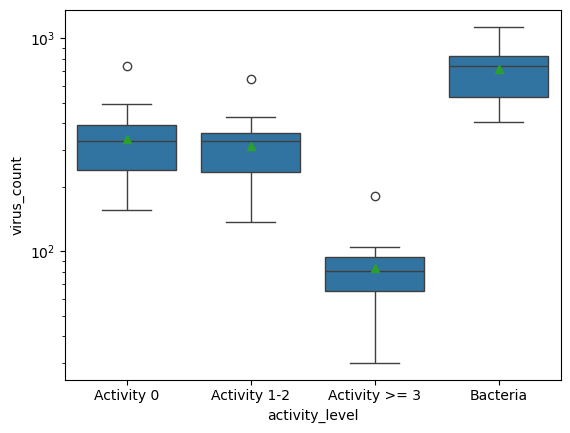

In [15]:
### Count number of viruses per coassembly group by activity level
virus_richness_activity = (
    ictv
        .join(max_activity, on=['coassembly_group', 'contig'], how='left')
        .group_by(['coassembly_group', 'activity_level'])
        .agg(pl.col('contig').n_unique().alias('virus_count'))
        .sort(['coassembly_group', 'activity_level'])
)

sns.boxplot(virus_richness_activity, x='activity_level', y='virus_count', showmeans=True)
plt.yscale('log')
# plt.ylim(1, 200)

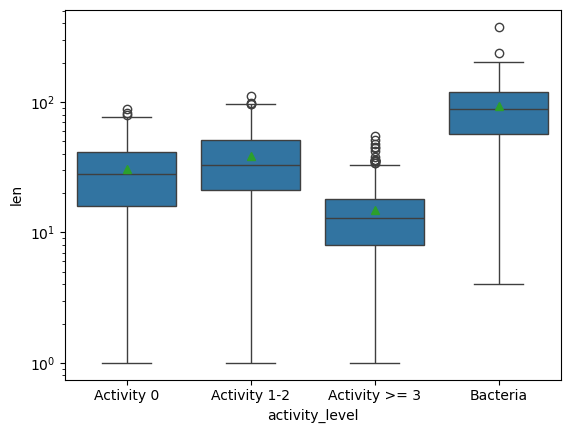

In [16]:
### Count number of viruses per coassembly group by activity level
virus_richness_activity = (
    ictv
        .join(max_activity, on=['coassembly_group', 'contig'], how='left')
        .group_by(['coassembly_group', 'activity_level', 'timepoint'])
        .len()
        .sort(['coassembly_group', 'activity_level'])
)

sns.boxplot(virus_richness_activity, x='activity_level', y='len', showmeans=True)
plt.yscale('log')
# plt.ylim(1, 200)

/tmp/ipykernel_81266/294014183.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


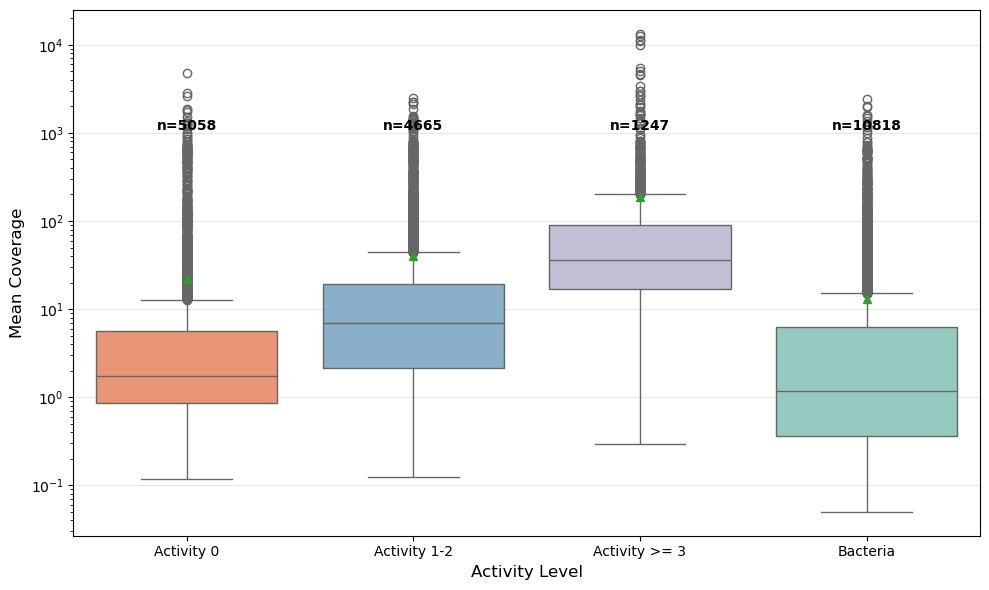

In [17]:
### Calculate virus coverage by activity level
# Calculate persistence for each virus
virus_cov = (
    bacphlip
        .group_by(['coassembly_group', 'contig', 'Family', 'genus'])
        .agg([
            pl.col('True_cov').max().alias('mean_cov')
        ])
        # .filter(pl.col('mean_cov') >= 10)
        .join(max_activity, on=['coassembly_group', 'contig'], how='left')
)


# Visualize persistence by activity level
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=virus_cov.to_pandas(),
    x='activity_level',
    y='mean_cov',
    order=['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria'],
    palette=['#FC8D62', '#80B1D3', '#BEBADA', '#8DD3C7'],
    showmeans=True
)

# Add counts above each boxplot
activity_order = ['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria']
for i, activity in enumerate(activity_order):
    count = len(virus_cov.filter(pl.col('activity_level') == activity))
    ax.text(i, 1000, f'n={count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Activity Level', fontsize=12)
plt.ylabel('Mean Coverage', fontsize=12)
plt.yscale('log')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

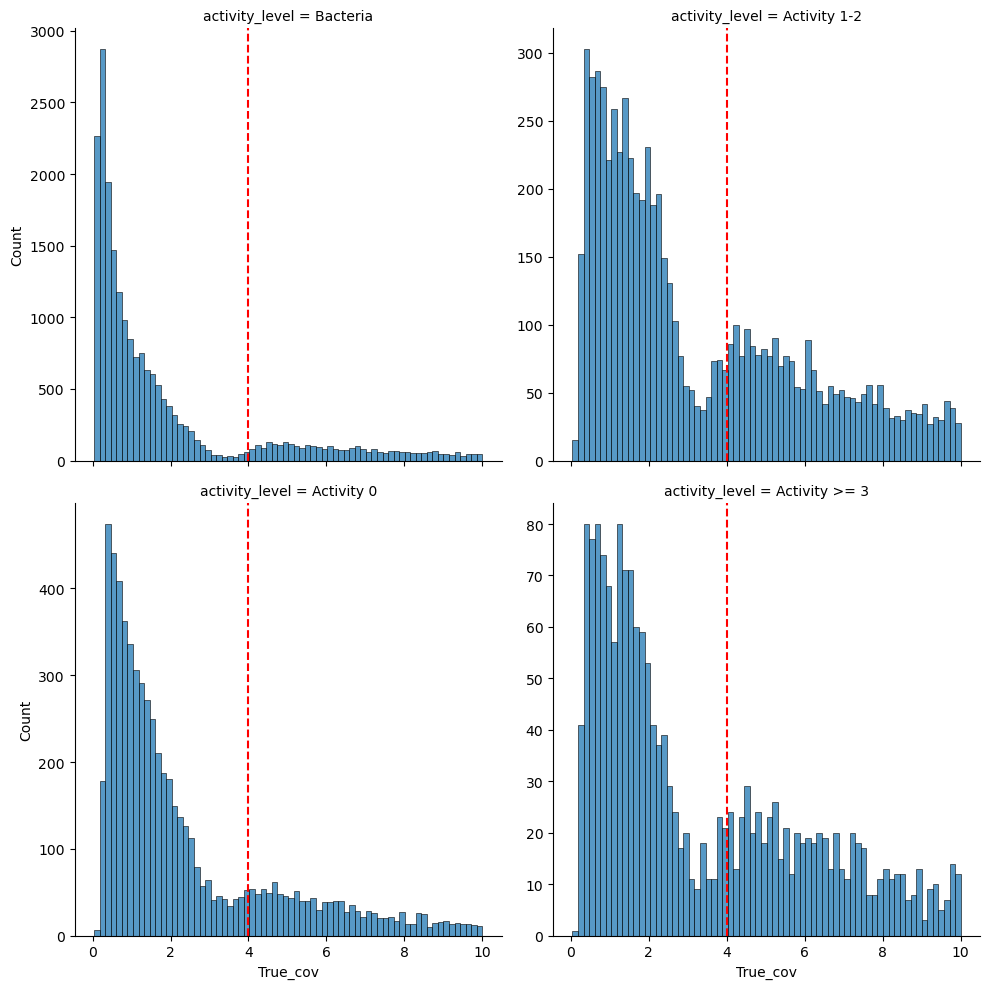

In [18]:
# plot faceted histogram of True_cov by activity_level
data = ictv.join(max_activity, on=['coassembly_group', 'contig'], how='inner').filter(pl.col('True_cov') <= 10)
sns.displot(data, x='True_cov', col='activity_level', col_wrap=2, log_scale=(False, False), facet_kws={'sharey': False})
# draw a vertical line at x=4
for ax in plt.gcf().axes:
    ax.axvline(x=4, color='red', linestyle='--')
plt.show()

/tmp/ipykernel_81266/714680045.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_81266/714680045.py:31: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(


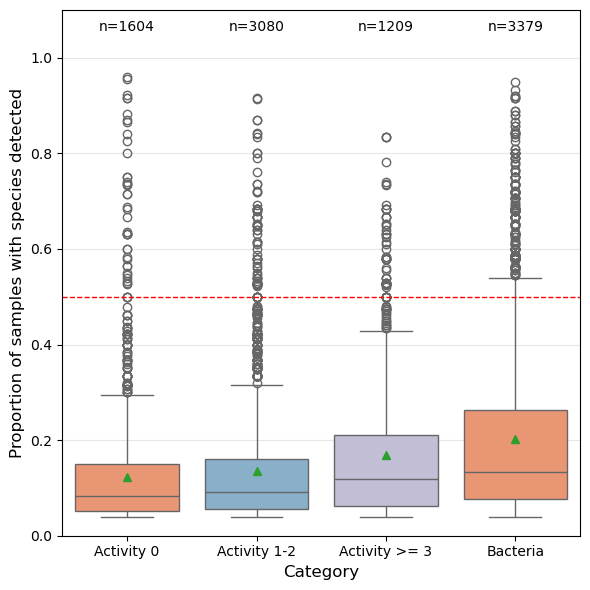

In [19]:
### Calculate virus persistence by activity level

# Get total number of samples per coassembly group
samples_per_group = (
    bacphlip
        .select(['coassembly_group', 'sample'])
        .unique()
        .group_by('coassembly_group')
        .agg(pl.col('sample').n_unique().alias('total_samples'))
)

# Calculate persistence for each virus
persistence = (
    bacphlip
        .group_by(['coassembly_group', 'contig', 'Family', 'genus', 'bac_genus'])
        .agg([
            pl.col('sample').n_unique().alias('samples_detected'),
            pl.col('True_cov').max().alias('max_cov'),
            pl.col('Sequence_abundance').max().alias('max_seq_abundance')
        ])
        .filter(pl.col('max_cov') >= 4)
        .join(samples_per_group, on='coassembly_group')
        .with_columns([
            (pl.col('samples_detected') / pl.col('total_samples')).alias('persistence')
        ])
        .join(max_activity, on=['coassembly_group', 'contig'], how='inner')
)

# Visualize persistence by activity level
plt.figure(figsize=(6, 6))
ax = sns.boxplot(
    data=persistence.to_pandas(),
    x='activity_level',
    y='persistence',
    order=['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria'],
    palette=['#FC8D62', '#80B1D3', '#BEBADA'],
    showmeans=True
)
# sns.stripplot(
#     data=plot_df.to_pandas(),
#     x='activity_level',
#     y='persistence',
#     order=['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria'],
#     color='black',
#     alpha=0.5
# )
# Add counts above each boxplot
activity_order = ['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria']
for i, activity in enumerate(activity_order):
    count = persistence.filter(pl.col('activity_level') == activity).unique(['contig', 'coassembly_group']).height
    ax.text(i, 1.05, f'n={count}', ha='center', va='bottom', fontsize=10,)

plt.xlabel('Category', fontsize=12)
plt.ylabel('Proportion of samples with species detected', fontsize=12)
plt.ylim(0,1.1)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
# add horizontal line at 0.5
plt.axhline(0.5, color='red', linestyle='--', linewidth=1)
plt.show()

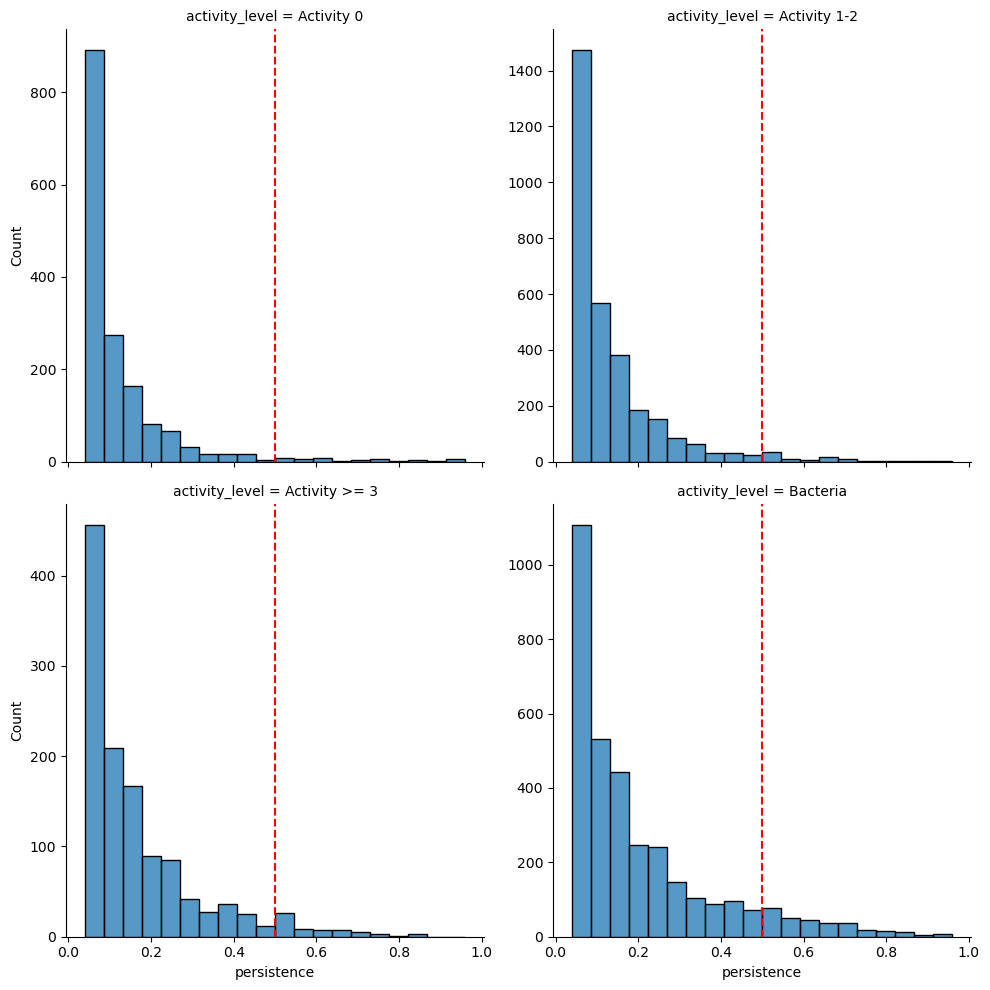

In [20]:
### Histogram of persistence values faceted by activity_level
sns.displot(
    persistence.to_pandas(),
    x='persistence', 
    col='activity_level', 
    col_wrap=2,
    col_order=['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria'],
    bins=20,
    facet_kws={'sharey': False}
)
plt.tight_layout()
# add vertical line at x=0.5
for ax in plt.gcf().axes:
    ax.axvline(x=0.5, color='red', linestyle='--')
plt.show()

/tmp/ipykernel_81266/1320731507.py:51: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns([
/tmp/ipykernel_81266/1320731507.py:105: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns([


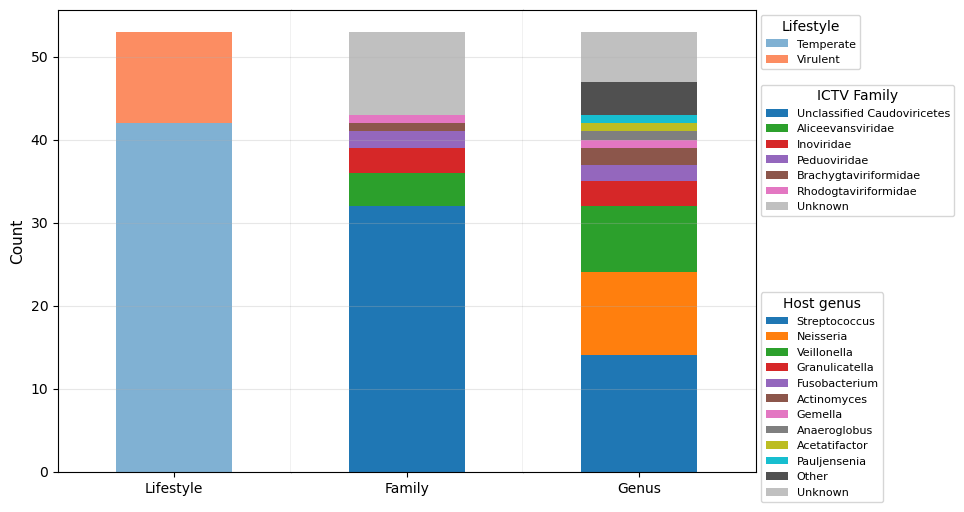

In [21]:
### Stacked barplots of persistent contig characteristics

# Filter for persistent contigs (persistence > 0.5) with activity level >= 3
persistent_contigs = (
    bacphlip
        .join(max_activity, on=['coassembly_group', 'contig'], how='left')
        .join(persistence[['coassembly_group', 'contig', 'persistence']], on=['coassembly_group', 'contig'], how='left')
        .filter(pl.col('persistence') > 0.5)
        .filter(pl.col('activity_level').is_in(['Activity >= 3']))
        .unique(['coassembly_group', 'contig', 'lifestyle', 'genus', 'Family', 'bac_genus', 'activity_level'])
)

# Create figure with 3 subplots (shared y-axis)
fig, axes = plt.subplots(1, 3, figsize=(9, 6), sharey=True)

# Get tab10 colors for all plots
tab10_colors = plt.cm.tab10(range(10))

# 1. Lifestyle stacked barplot
lifestyle_data = (
    persistent_contigs
        .filter(pl.col('lifestyle').is_not_null())
        .group_by(['lifestyle'])
        .agg(pl.len().alias('Lifestyle'))
)

lifestyle_df = lifestyle_data.sort('Lifestyle', descending=True).select(['lifestyle', 'Lifestyle']).to_pandas().set_index('lifestyle').T

lifestyle_df.plot(kind='bar', stacked=True, ax=axes[0], color=['#80B1D3', '#FC8D62'], legend=True)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=8, bbox_to_anchor=(3, 1), loc='upper left', title='Lifestyle')
axes[0].grid(alpha=0.3, axis='y')

# 2. Top 10 Family stacked barplot with Other and Unknown categories
top_family = (
    persistent_contigs
        .filter(pl.col('Family').is_not_null())
        .group_by('Family')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
        .head(10)
        ['Family']
)

# Categorize families into top 10, other, or unknown
family_categorized = (
    persistent_contigs
        .filter(pl.col('activity_level') != 'Bacteria')
        .with_columns([
            pl.when(pl.col('Family').is_null())
                .then(pl.lit('Unknown'))
            .when(pl.col('Family') == 'No family assignment')
                .then(pl.lit('Unknown'))
            .when(pl.col('Family').is_in(top_family))
                .then(pl.col('Family'))
            .otherwise(pl.lit('Other'))
            .alias('family_category')
        ])
)

family_data = (
    family_categorized
        .group_by(['family_category'])
        .agg(pl.len().alias('Family'))
)
family_df = family_data.select(['family_category', 'Family']).to_pandas().set_index('family_category').T

# Define color map with top 10 from tab10, dark grey for Other, light grey for Unknown
family_color_map = {}
for i, family in enumerate(list(top_family)):
    family_color_map[family] = tab10_colors[i]
family_color_map['Other'] = '#505050'  # dark grey
family_color_map['Unknown'] = '#C0C0C0'  # light grey

# Reorder columns to have Unknown and Other at the end
family_col_order = [f for f in list(top_family) if f in family_df.columns] + \
                   (['Other'] if 'Other' in family_df.columns else []) + \
                   (['Unknown'] if 'Unknown' in family_df.columns else [])
family_df = family_df[[c for c in family_col_order if c in family_df.columns]]

family_colors = [family_color_map[col] for col in family_df.columns]
family_df.plot(kind='bar', stacked=True, ax=axes[1], color=family_colors, legend=True)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=8, bbox_to_anchor=(2, 0.85), loc='upper left', title='ICTV Family')
axes[1].grid(alpha=0.3, axis='y')

# 3. Top 10 Host Genus stacked barplot with Other and Unknown categories
top_genus = (
    persistent_contigs
        .filter(pl.col('genus').is_not_null())
        .group_by('genus')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
        .head(10)
        ['genus']
)

# Categorize genera into top 10, other, or unknown
genus_categorized = (
    persistent_contigs
        .filter(pl.col('activity_level') != 'Bacteria')
        .with_columns([
            pl.when(pl.col('genus').is_null())
                .then(pl.lit('Unknown'))
            .when(pl.col('genus').is_in(top_genus))
                .then(pl.col('genus'))
            .otherwise(pl.lit('Other'))
            .alias('genus_category')
        ])
)

genus_data = (
    genus_categorized
        .group_by(['genus_category'])
        .agg(pl.len().alias('Genus'))
)

genus_df = genus_data.select(['genus_category', 'Genus']).to_pandas().set_index('genus_category').T

# Define color map with top 10 from tab10, dark grey for Other, light grey for Unknown
color_map = {}
top_genus_list = list(top_genus)
for i, genus in enumerate(top_genus_list):
    color_map[genus] = tab10_colors[i]
color_map['Other'] = '#505050'  # dark grey
color_map['Unknown'] = '#C0C0C0'  # light grey

# Reorder columns to have Unknown and Other at the end
col_order = [g for g in top_genus_list if g in genus_df.columns] + \
            (['Other'] if 'Other' in genus_df.columns else []) + \
            (['Unknown'] if 'Unknown' in genus_df.columns else [])
genus_df = genus_df[[c for c in col_order if c in genus_df.columns]]

colors = [color_map[col] for col in genus_df.columns]
genus_df.plot(kind='bar', stacked=True, ax=axes[2], color=colors, legend=True)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(fontsize=8, bbox_to_anchor=(1, 0.4), loc='upper left', title='Host genus')
axes[2].grid(alpha=0.3, axis='y')

# Remove spines between subplots for seamless appearance
for i in range(1, 3):
    axes[i].spines['left'].set_visible(False)
    axes[i].tick_params(left=False)

plt.subplots_adjust(wspace=0.0)
plt.show()

In [22]:
persistent_contigs

sample,timepoint,coassembly_group,genome_id,contig,breadth_ratio,activity_score,genus,bac_genus,True_cov,Sequence_abundance,Taxonomic_abundance,Family,temperate,lifestyle,genome_id_right,max_activity_score,max_breadth,activity_level,persistence
str,date,str,str,str,f64,f64,str,str,f64,f64,f64,str,f64,str,str,f64,f64,str,f64
"""SAMN33100628_SRR23346236_cf""",2018-07-25,"""1""","""uhvdb_votu_reps""","""SAMN33100408_SRR23346285_cf_k2…",0.991624,4.0,"""Streptococcus""",null,22.001,0.0435,0.3893,"""Aliceevansviridae""",0.9625,"""Temperate""","""uhvdb_votu_reps""",7.0,0.999906,"""Activity >= 3""",0.736842
"""SAMN33100435_SRR23346192_cf""",2020-09-09,"""1""","""uhvdb_votu_reps""","""SAMN33100415_SRR23346119_cf_k2…",0.927194,1.0,"""Streptococcus""",null,1.821,0.0165,0.1401,"""Unclassified Caudoviricetes""",0.975,"""Temperate""","""uhvdb_votu_reps""",4.0,1.0,"""Activity >= 3""",0.526316
"""SAMN33100435_SRR23346192_cf""",2020-09-09,"""1""","""uhvdb_votu_reps""","""SAMN33100646_SRR23346217_cf_k2…",0.686204,0.0,"""Streptococcus""",null,1.369,0.0144,0.1053,"""Unclassified Caudoviricetes""",1.0,"""Temperate""","""uhvdb_votu_reps""",4.0,1.0,"""Activity >= 3""",0.578947
"""SAMN33100453_SRR23346035_cf""",2016-06-22,"""4""","""uhvdb_votu_reps""","""SAMN33100453_SRR23346035_cf_k2…",1.0,4.0,"""Veillonella""",null,63.351,0.0961,1.232,"""No family assignment""",1.0,"""Temperate""","""uhvdb_votu_reps""",7.0,1.0,"""Activity >= 3""",0.666667
"""SAMN33100476_SRR23346082_cf""",2016-08-24,"""2""","""uhvdb_votu_reps""","""SAMN33100400_SRR23346062_cf_k2…",0.382901,0.0,"""Veillonella""",null,0.294,0.0008,0.0077,"""Unclassified Caudoviricetes""",0.9625,"""Temperate""","""uhvdb_votu_reps""",7.0,1.0,"""Activity >= 3""",0.652174
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SAMN33100613_SRR23346253_cf""",2018-04-11,"""4""","""uhvdb_votu_reps""","""SAMN33100427_SRR23346201_cf_k2…",0.99998,4.0,null,null,17.058,0.0837,0.9964,"""Unclassified Caudoviricetes""",0.85,"""Temperate""","""uhvdb_votu_reps""",4.0,1.000001,"""Activity >= 3""",0.733333
"""SAMN33100646_SRR23346217_cf""",2018-10-24,"""1""","""uhvdb_votu_reps""","""SAMN33100415_SRR23346119_cf_k2…",1.0,7.0,"""Granulicatella""",null,41.135,0.0246,0.3363,"""Unclassified Caudoviricetes""",0.096669,"""Virulent""","""uhvdb_votu_reps""",10.0,1.0,"""Activity >= 3""",0.578947
"""SAMN33100480_SRR23346077_cf""",2015-06-11,"""1""","""uhvdb_votu_reps""","""ERZ21615931.3970""",0.985692,4.0,"""Neisseria""",null,95.476,0.0151,0.7974,"""No family assignment""",0.004956,"""Virulent""","""uhvdb_votu_reps""",4.0,0.988186,"""Activity >= 3""",0.526316


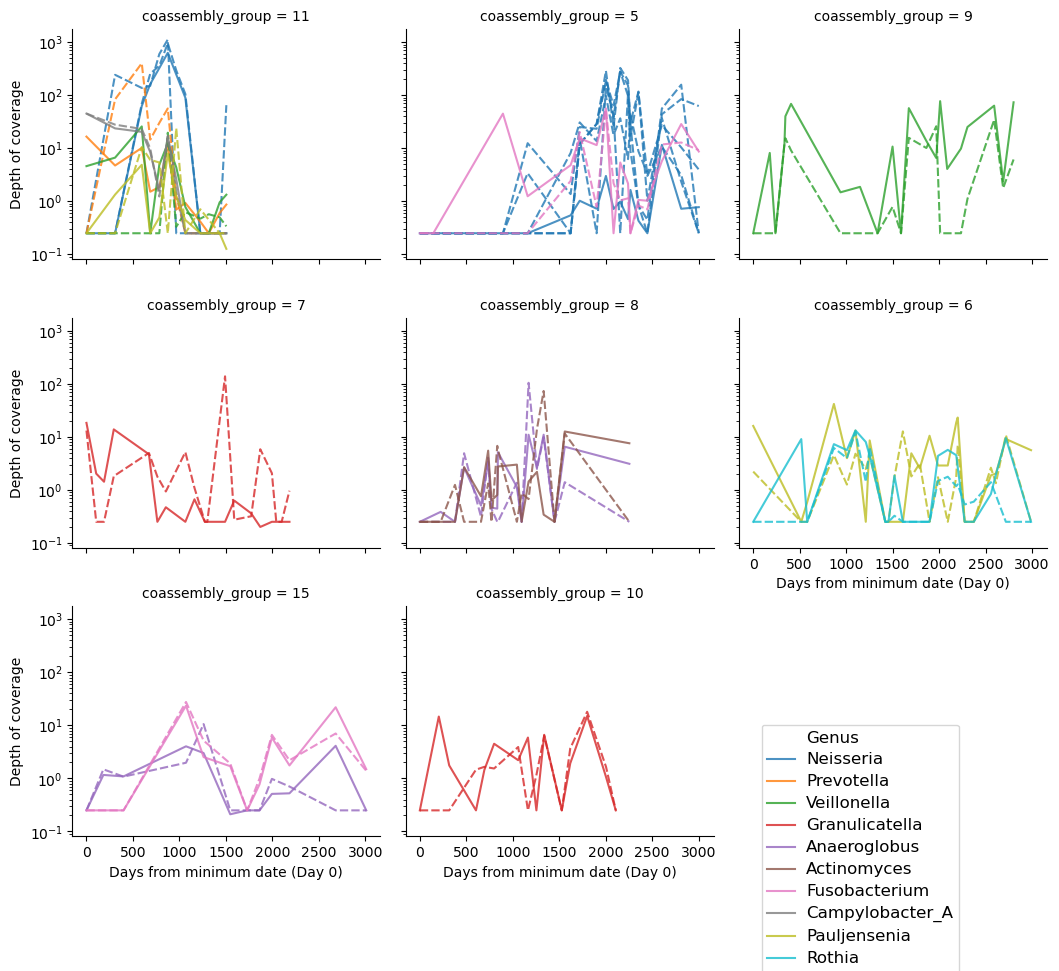

In [31]:
### Lineplot of viral taxonomic abundance over time (normalized to day 0)
# Get minimum date for each coassembly group
min_date_per_group = (
    bacphlip
        .group_by('coassembly_group')
        .agg(pl.col('timepoint').min().alias('min_timepoint'))
)

# Join with min date and calculate days from minimum
time_normalized = (
    bacphlip
        .join(min_date_per_group, on='coassembly_group', how='inner')
        .join(min_date_per_group, on='coassembly_group')
        .with_columns([
            (pl.col('timepoint') - pl.col('min_timepoint')).dt.total_days().alias('days_from_min')
        ])
)


# Filter for viruses with high coverage and get their trajectories
virus_traj_filtered = (
    time_normalized
        .join(persistence.select(['coassembly_group', 'contig', 'samples_detected', 'total_samples', 'activity_level', 'persistence']), on=['coassembly_group', 'contig'], how='inner')
        .filter(pl.col('persistence') >= 0.5)
        # .filter(~pl.col('activity_level').is_in(['Activity 0', 'Activity 1-2']))
)

# Create all possible combinations and join to fill missing values with 0
all_activity_levels = virus_traj_filtered.select('activity_level').unique()

all_combinations = (
    virus_traj_filtered
        .select(['coassembly_group', 'days_from_min']).unique()
        .join(
            virus_traj_filtered.select(['coassembly_group', 'contig', 'genus', 'bac_genus']).unique(),
            on='coassembly_group',
            how='inner'
        )
        .join(all_activity_levels, how='cross')
)

virus_trajectories = (
    all_combinations
        .join(virus_traj_filtered, on=['coassembly_group', 'contig', 'days_from_min', 'activity_level'], how='left')
        .with_columns([
            pl.col('True_cov').fill_null(0.25),
            pl.col('Taxonomic_abundance').fill_null(0.25),
        ])
        .sort('True_cov', descending=True)
        .unique(subset=['coassembly_group', 'contig', 'days_from_min', 'activity_level'], maintain_order=True)
)

# Remove contigs that are 0.1 at every timepoint within a coassembly group
contigs_to_keep = (
    virus_trajectories
        .group_by(['coassembly_group', 'contig', 'activity_level'])
        .agg(pl.col('True_cov').max().alias('max_true_cov'))
        .filter(pl.col('max_true_cov') > 0.25)
)

# create dict of contig to family
inovirus_set = set(
    virus_traj_filtered
        .filter(pl.col('Family') == 'Inoviridae')
        ['contig']
)

test = (
    virus_trajectories
        .join(contigs_to_keep, on=['coassembly_group', 'contig', 'activity_level'], how='inner')
        .with_columns([
            pl.when(pl.col('contig').is_in(inovirus_set))
                .then(pl.lit('Inoviridae'))
                .otherwise(pl.lit('Other'))
                .alias('family_style')
        ])
)

coassembly_with_bacteria = (
    virus_traj_filtered
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group'])
        .unique()
)

coassembly_with_virus = (
    virus_traj_filtered
        .filter(pl.col('activity_level').is_in(['Activity >= 3']))
        .select(['coassembly_group'])
        .unique()
)

coassembly_with_both = (
    coassembly_with_virus
        .join(coassembly_with_bacteria, on='coassembly_group', how='inner')
)

test = (
    test
        .join(coassembly_with_both, on='coassembly_group', how='inner')
        .with_columns([
            pl.when(pl.col('bac_genus').is_not_null()).then(pl.col('bac_genus'))
                .when(pl.col('genus').is_not_null()).then(pl.col('genus'))
                .otherwise(pl.lit('Unknown'))
                .alias('Genus')
        ])
)

# filter to genus with both bacteria and phage
genus_with_both = (
    test
        # .filter(pl.col('Genus').is_in(['Pseudomonas', 'Staphylococcus', 'Streptococcus', 'Rothia', 'Bulleidia', 'Prevotella', 'Actinomyces', 'Lancefieldella', 'Porphyromonas', 'Gemella', 'Veillonella', 'Fusobacterium']))
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group', 'Genus'])
        .unique()
        .join(
            test
            .filter(pl.col('activity_level').is_in(['Activity >= 3']))
                .select(['coassembly_group', 'Genus'])
                .unique(),
            on=['coassembly_group', 'Genus'],
            how='inner'
        )
)

test = (
    test
        .join(genus_with_both, on=['coassembly_group', 'Genus'], how='inner')
)

# Filter out bac_genus groups with more than one contig per coassembly_group
bac_genus_contig_counts = (
    test
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group', 'bac_genus', 'contig'])
        .unique()
        .group_by(['coassembly_group', 'bac_genus'])
        .agg(pl.col('contig').n_unique().alias('contig_count'))
        .filter(pl.col('contig_count') <= 1)
        .select(['coassembly_group', 'bac_genus'])
)

final = (
    test
        .join(bac_genus_contig_counts, left_on=['coassembly_group', 'Genus'], right_on=['coassembly_group', 'bac_genus'], how='inner', coalesce=True)
)


# Create faceted lineplot by coassembly_group
palette = {
    'Bacteria': 'black',
    'Activity >= 3': 'red'
}

g = sns.relplot(
    data=final.rename({'activity_level':'Category', 'family_style':'ICTV Family'}), 
    x='days_from_min', 
    y='True_cov', 
    col='coassembly_group',
    col_wrap=3,
    kind='line',
    hue='Genus',
    style='Category',
    style_order=['Bacteria','Activity >= 3'],
    # palette=palette,
    height=3,
    aspect=1,
    alpha=0.8,
    units='contig',
    estimator=None
)

g.set_axis_labels('Days from minimum date (Day 0)', 'Depth of coverage')

# move legend to lower right corner
g._legend.set_bbox_to_anchor((0.9, 0.10))
# add background to legend
g._legend.set_frame_on(True)
# increase legend text size
for text in g._legend.texts:
    text.set_fontsize(12)
# set date range for x axis
# plt.xlim(2010,2025)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [32]:
activity_levels = ['Activity 0', 'Activity 1-2', 'Activity >= 3']
num_bac_per_genus = 1000

In [33]:
from itertools import product
import numpy as np
import polars as pl
from scipy.stats import spearmanr



### Lineplot of viral taxonomic abundance over time (normalized to day 0)
# Get minimum date for each coassembly group
min_date_per_group = (
    bacphlip
        .group_by('coassembly_group')
        .agg(pl.col('timepoint').min().alias('min_timepoint'))
)

# Join with min date and calculate days from minimum
time_normalized = (
    bacphlip
        .join(min_date_per_group, on='coassembly_group', how='inner')
        .with_columns([
            (pl.col('timepoint') - pl.col('min_timepoint')).dt.total_days().alias('days_from_min')
        ])
)


# Filter for viruses with high coverage and get their trajectories
virus_traj_filtered = (
    time_normalized
        .join(persistence.select(['coassembly_group', 'contig', 'samples_detected', 'total_samples', 'activity_level', 'persistence']), on=['coassembly_group', 'contig'], how='inner')
        .filter(pl.col('persistence') >= 0.5)
        # .filter(~pl.col('activity_level').is_in(['Activity 0', 'Activity 1-2']))
)

# Create all possible combinations and join to fill missing values with 0
all_activity_levels = virus_traj_filtered.select('activity_level').unique()

all_combinations = (
    virus_traj_filtered
        .select(['coassembly_group', 'days_from_min']).unique()
        .join(
            virus_traj_filtered.select(['coassembly_group', 'contig', 'genus', 'bac_genus']).unique(),
            on='coassembly_group',
            how='inner'
        )
        .join(all_activity_levels, how='cross')
)

virus_trajectories = (
    all_combinations
        .join(virus_traj_filtered, on=['coassembly_group', 'contig', 'days_from_min', 'activity_level'], how='left')
        .with_columns([
            pl.col('True_cov').fill_null(0.25),
            pl.col('Taxonomic_abundance').fill_null(0.25),
        ])
        .sort('True_cov', descending=True)
        .unique(subset=['coassembly_group', 'contig', 'days_from_min', 'activity_level'], maintain_order=True)
)

# Remove contigs that are 0.1 at every timepoint within a coassembly group
contigs_to_keep = (
    virus_trajectories
        .group_by(['coassembly_group', 'contig', 'activity_level'])
        .agg(pl.col('True_cov').max().alias('max_true_cov'))
        .filter(pl.col('max_true_cov') > 0.25)
)

# create dict of contig to family
inovirus_set = set(
    virus_traj_filtered
        .filter(pl.col('Family') == 'Inoviridae')
        ['contig']
)

test = (
    virus_trajectories
        .join(contigs_to_keep, on=['coassembly_group', 'contig', 'activity_level'], how='inner')
        .with_columns([
            pl.when(pl.col('contig').is_in(inovirus_set))
                .then(pl.lit('Inoviridae'))
                .otherwise(pl.lit('Other'))
                .alias('family_style')
        ])
)

coassembly_with_bacteria = (
    virus_traj_filtered
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group'])
        .unique()
)

coassembly_with_virus = (
    virus_traj_filtered
        .filter(pl.col('activity_level').is_in(activity_levels))
        .select(['coassembly_group'])
        .unique()
)

coassembly_with_both = (
    coassembly_with_virus
        .join(coassembly_with_bacteria, on='coassembly_group', how='inner')
)

test = (
    test
        .join(coassembly_with_both, on='coassembly_group', how='inner')
        .with_columns([
            pl.when(pl.col('bac_genus').is_not_null()).then(pl.col('bac_genus'))
                .when(pl.col('genus').is_not_null()).then(pl.col('genus'))
                .otherwise(pl.lit('Unknown'))
                .alias('Genus')
        ])
)

# filter to genus with both bacteria and phage
genus_with_both = (
    test
        # .filter(pl.col('Genus').is_in(['Pseudomonas', 'Staphylococcus', 'Streptococcus', 'Rothia', 'Bulleidia', 'Prevotella', 'Actinomyces', 'Lancefieldella', 'Porphyromonas', 'Gemella', 'Veillonella', 'Fusobacterium']))
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group', 'Genus'])
        .unique()
        .join(
            test
            .filter(pl.col('activity_level').is_in(activity_levels))
                .select(['coassembly_group', 'Genus'])
                .unique(),
            on=['coassembly_group', 'Genus'],
            how='inner'
        )
)

test = (
    test
        .join(genus_with_both, on=['coassembly_group', 'Genus'], how='inner')
)

# Filter out bac_genus groups with more than one contig per coassembly_group
bac_genus_contig_counts = (
    test
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group', 'bac_genus', 'contig'])
        .unique()
        .group_by(['coassembly_group', 'bac_genus'])
        .agg(pl.col('contig').n_unique().alias('contig_count'))
        .filter(pl.col('contig_count') <= num_bac_per_genus)
        .select(['coassembly_group', 'bac_genus'])
)

final = (
    test
        .join(bac_genus_contig_counts, left_on=['coassembly_group', 'Genus'], right_on=['coassembly_group', 'bac_genus'], how='inner', coalesce=True)
)

# Expecting `test` with columns: coassembly_group, Genus, contig, activity_level, days_from_min, True_cov
# Split bacteria and phage contigs
bacteria = (
    final
    .filter(pl.col("activity_level") == "Bacteria")
    .select(["coassembly_group", "Genus", "contig", "days_from_min", "True_cov"])
    .rename({"contig": "bac_contig", "True_cov": "bac_cov"})
)

phage = (
    final
    .filter(pl.col("activity_level").is_in(activity_levels))
    .select(["coassembly_group", "Genus", "contig", "days_from_min", "True_cov", "activity_level"])
    .rename({"contig": "phage_contig", "True_cov": "phage_cov"})
)

# Join by coassembly_group, Genus, and time so trajectories align
paired = (
    bacteria.join(
        phage,
        on=["coassembly_group", "Genus", "days_from_min"],
        how="inner"
    )
)

# Compute Spearman for each phage-bacteria contig pair within a subject/genus
def spearman_from_lists(s):
    x = np.array(s["bac_cov_list"])
    y = np.array(s["phage_cov_list"])
    if len(x) < 2 or np.all(x == x[0]) or np.all(y == y[0]):
        return {"spearman_rho": np.nan, "spearman_pval": np.nan}
    rho, pval = spearmanr(x, y)
    return {"spearman_rho": rho, "spearman_pval": pval}

spearman_df = (
    paired
    .group_by(["coassembly_group", "Genus", "bac_contig", "phage_contig", "activity_level"])
    .agg([
        pl.col("bac_cov").alias("bac_cov_list"),
        pl.col("phage_cov").alias("phage_cov_list"),
        pl.len().alias("n_timepoints"),
    ])
    .with_columns(
        pl.struct(["bac_cov_list", "phage_cov_list"])
        .map_elements(spearman_from_lists)
        .alias("stats")
    )
    .unnest("stats")
    .drop(["bac_cov_list", "phage_cov_list"])
    .sort(["coassembly_group", "Genus", "spearman_rho"], descending=[False, False, True])
)


/tmp/ipykernel_81266/2829140737.py:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


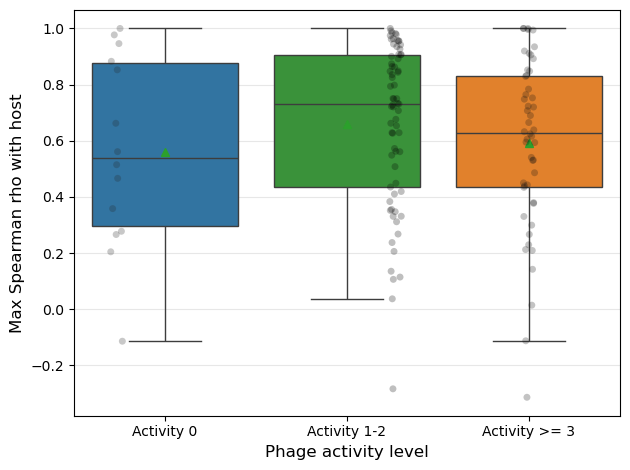

In [34]:
top_spearman_per_phage = (
    spearman_df
            .group_by(['coassembly_group', 'phage_contig', 'Genus', 'activity_level'])
            .agg([
                pl.col('spearman_pval').min(),
                pl.col('spearman_rho').max()
            ])
)

# create a boxplot of spearman rho by activity level
sns.boxplot(
    top_spearman_per_phage,
    x='activity_level',
    y='spearman_rho',
    hue='activity_level',
    order=activity_levels,
    showmeans=True,
    showfliers=False
)
sns.stripplot(
    top_spearman_per_phage,
    x='activity_level',
    y='spearman_rho',
    hue='activity_level',
    order=activity_levels,
    dodge=True,
    color='black',
    alpha=0.25,
)
plt.xlabel('Phage activity level', fontsize=12)
plt.ylabel('Max Spearman rho with host', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [35]:
from scipy.stats import mannwhitneyu

# Prepare data
activity_0 = top_spearman_per_phage.filter(pl.col('activity_level') == 'Activity 0')['spearman_rho'].to_numpy()
activity_1_2 = top_spearman_per_phage.filter(pl.col('activity_level') == 'Activity 1-2')['spearman_rho'].to_numpy()
activity_3plus = top_spearman_per_phage.filter(pl.col('activity_level') == 'Activity >= 3')['spearman_rho'].to_numpy()

# Remove NaN values
activity_0 = activity_0[~np.isnan(activity_0)]
activity_1_2 = activity_1_2[~np.isnan(activity_1_2)]
activity_3plus = activity_3plus[~np.isnan(activity_3plus)]

# Pairwise Mann-Whitney U tests
comparisons = [
    ('Activity 0', 'Activity 1-2', activity_0, activity_1_2),
    ('Activity 0', 'Activity >= 3', activity_0, activity_3plus),
    ('Activity 1-2', 'Activity >= 3', activity_1_2, activity_3plus)
]

print("Pairwise Mann-Whitney U tests (Bonferroni corrected α = 0.0167):")
print("-" * 70)
for group1, group2, data1, data2 in comparisons:
    stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"{group1} vs {group2}:")
    print(f"  U-statistic: {stat:.2f}, p-value: {p_val:.4} {sig}")
    print(f"  n1={len(data1)}, n2={len(data2)}")
    print()

from scipy.stats import kruskal

stat, p_value = kruskal(activity_0, activity_1_2, activity_3plus)
print(f"Kruskal-Wallis H-test:")
print(f"  H-statistic: {stat:.4f}, p-value: {p_value:.4f}")

Pairwise Mann-Whitney U tests (Bonferroni corrected α = 0.0167):
----------------------------------------------------------------------
Activity 0 vs Activity 1-2:
  U-statistic: 409.50, p-value: 0.3747 ns
  n1=14, n2=69

Activity 0 vs Activity >= 3:
  U-statistic: 329.00, p-value: 0.7392 ns
  n1=14, n2=50

Activity 1-2 vs Activity >= 3:
  U-statistic: 1962.00, p-value: 0.2029 ns
  n1=69, n2=50

Kruskal-Wallis H-test:
  H-statistic: 1.9986, p-value: 0.3681


In [36]:
highest_rho_per_phage = (
    spearman_df
    .group_by(['coassembly_group', 'phage_contig', 'Genus', 'activity_level'])
    .agg([
        pl.col('spearman_rho').max().alias('max_spearman_rho'),
    ])
    .join(
        spearman_df,
        on=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'],
        how='inner'
    )
    .filter(pl.col('spearman_rho') == pl.col('max_spearman_rho'))
    .unique(subset=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'], maintain_order=True)
)

# calculate proportion with p-value <= 0.05 for each activity level
(
    highest_rho_per_phage
    .filter(pl.col('spearman_rho') > 0)
    .group_by('activity_level')
    .agg([
        pl.col('spearman_pval').filter(pl.col('spearman_pval') <= 0.05).count().alias('sig_count'),
        pl.col('spearman_pval').count().alias('total_count'),
        (pl.col('spearman_pval').filter(pl.col('spearman_pval') <= 0.05).count() / pl.col('spearman_pval').count()).alias('proportion_sig')
    ])
)

activity_level,sig_count,total_count,proportion_sig
str,u32,u32,f64
"""Activity >= 3""",35,48,0.729167
"""Activity 0""",8,13,0.615385
"""Activity 1-2""",50,68,0.735294


In [37]:
lowest_rho_per_phage = (
    spearman_df
    .group_by(['coassembly_group', 'phage_contig', 'Genus', 'activity_level'])
    .agg([
        pl.col('spearman_rho').min().alias('min_spearman_rho'),
    ])
    .join(
        spearman_df,
        on=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'],
        how='inner'
    )
    .filter(pl.col('spearman_rho') == pl.col('min_spearman_rho'))
    .unique(subset=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'], maintain_order=True)
)

# calculate proportion with p-value <= 0.05 for each activity level
(
    lowest_rho_per_phage
    .filter(pl.col('spearman_rho') < 0)
    .group_by('activity_level')
    .agg([
        pl.col('spearman_pval').filter(pl.col('spearman_pval') <= 0.05).count().alias('sig_count'),
        pl.col('spearman_pval').count().alias('total_count'),
        (pl.col('spearman_pval').filter(pl.col('spearman_pval') <= 0.05).count() / pl.col('spearman_pval').count()).alias('proportion_sig')
    ])
)

activity_level,sig_count,total_count,proportion_sig
str,u32,u32,f64
"""Activity 0""",1,3,0.333333
"""Activity >= 3""",0,18,0.0
"""Activity 1-2""",1,13,0.076923


In [44]:
lowest_rho_per_phage.filter(pl.col('spearman_rho') < 0).filter(pl.col('spearman_pval') <= 0.05)

coassembly_group,phage_contig,Genus,activity_level,min_spearman_rho,bac_contig,n_timepoints,spearman_rho,spearman_pval
str,str,str,str,f64,str,u32,f64,f64
"""1""","""ERZ772953.475""","""Streptococcus""","""Activity 1-2""",-0.51735,"""MOTU40_010390_000000000001""",19,-0.51735,0.023299
"""2""","""SAMEA10740676_k141_165178""","""Neisseria""","""Activity 0""",-0.448863,"""GCF_023472875_000000000001""",23,-0.448863,0.031678


In [48]:
genus = 'Neisseria'
coassembly_group = '2'
phage_contig = 'SAMEA10740676_k141_165178'
bac_contig = 'GCF_023472875_000000000001'

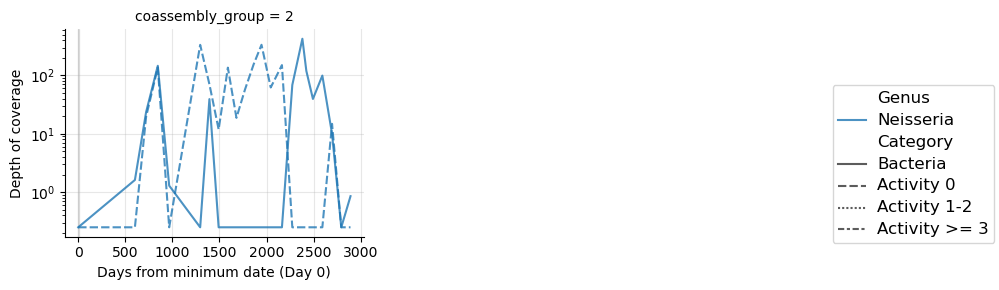

In [49]:
### Lineplot of viral taxonomic abundance over time (normalized to day 0)
# Get minimum date for each coassembly group
min_date_per_group = (
    bacphlip
        .group_by('coassembly_group')
        .agg(pl.col('timepoint').min().alias('min_timepoint'))
)

# Join with min date and calculate days from minimum
time_normalized = (
    bacphlip
        .join(min_date_per_group, on='coassembly_group', how='inner')
        .with_columns([
            (pl.col('timepoint') - pl.col('min_timepoint')).dt.total_days().alias('days_from_min')
        ])
)


# Filter for viruses with high coverage and get their trajectories
virus_traj_filtered = (
    time_normalized
        .join(persistence.select(['coassembly_group', 'contig', 'samples_detected', 'total_samples', 'activity_level']), on=['coassembly_group', 'contig'], how='inner')
        .filter(pl.col('total_samples') >= 3)
        .filter(pl.col('samples_detected') > 2)
        # .filter(~pl.col('activity_level').is_in(['Activity 0', 'Activity 1-2']))
)

# Create all possible combinations and join to fill missing values with 0
all_activity_levels = virus_traj_filtered.select('activity_level').unique()

all_combinations = (
    virus_traj_filtered
        .select(['coassembly_group', 'days_from_min']).unique()
        .join(
            virus_traj_filtered.select(['coassembly_group', 'contig', 'genus', 'bac_genus']).unique(),
            on='coassembly_group',
            how='inner'
        )
        .join(all_activity_levels, how='cross')
)

virus_trajectories = (
    all_combinations
        .join(virus_traj_filtered, on=['coassembly_group', 'contig', 'days_from_min', 'activity_level'], how='left')
        .with_columns([
            pl.col('True_cov').fill_null(0.25),
            pl.col('Taxonomic_abundance').fill_null(0.25),
        ])
        .sort('True_cov', descending=True)
        .unique(subset=['coassembly_group', 'contig', 'days_from_min', 'activity_level'], maintain_order=True)
)

# Remove contigs that are 0.1 at every timepoint within a coassembly group
contigs_to_keep = (
    virus_trajectories
        .group_by(['coassembly_group', 'contig', 'activity_level'])
        .agg(pl.col('True_cov').max().alias('max_true_cov'))
        .filter(pl.col('max_true_cov') > 0.25)
)

# create dict of contig to family
inovirus_set = set(
    virus_traj_filtered
        .filter(pl.col('Family') == 'Inoviridae')
        ['contig']
)

test = (
    virus_trajectories
        .join(contigs_to_keep, on=['coassembly_group', 'contig', 'activity_level'], how='inner')
        .with_columns([
            pl.when(pl.col('contig').is_in(inovirus_set))
                .then(pl.lit('Inoviridae'))
                .otherwise(pl.lit('Other'))
                .alias('family_style')
        ])
)

coassembly_with_bacteria = (
    virus_traj_filtered
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group'])
        .unique()
)

coassembly_with_virus = (
    virus_traj_filtered
        .filter(pl.col('activity_level').is_in(['Activity 0', 'Activity 1-2', 'Activity >= 3']))
        .select(['coassembly_group'])
        .unique()
)

coassembly_with_both = (
    coassembly_with_virus
        .join(coassembly_with_bacteria, on='coassembly_group', how='inner')
)

test = (
    test
        .join(coassembly_with_both, on='coassembly_group', how='inner')
        .with_columns([
            pl.when(pl.col('bac_genus').is_not_null()).then(pl.col('bac_genus'))
                .when(pl.col('genus').is_not_null()).then(pl.col('genus'))
                .otherwise(pl.lit('Unknown'))
                .alias('Genus')
        ])
)

# filter to genus with both bacteria and phage
genus_with_both = (
    test
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group', 'Genus'])
        .unique()
        .join(
            test
            .filter(pl.col('activity_level').is_in(['Activity 0', 'Activity 1-2', 'Activity >= 3']))
                .select(['coassembly_group', 'Genus'])
                .unique(),
            on=['coassembly_group', 'Genus'],
            how='inner'
        )
)

test = (
    test
        .join(genus_with_both, on=['coassembly_group', 'Genus'], how='inner')
)

# Filter out bac_genus groups with more than one contig per coassembly_group
bac_genus_contig_counts = (
    test
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group', 'bac_genus', 'contig'])
        .unique()
        .group_by(['coassembly_group', 'bac_genus'])
        .agg(pl.col('contig').n_unique().alias('contig_count'))
        .select(['coassembly_group', 'bac_genus'])
)

final = (
    test
        .join(bac_genus_contig_counts, left_on=['coassembly_group', 'Genus'], right_on=['coassembly_group', 'bac_genus'], how='inner', coalesce=True)
        .filter(pl.col('coassembly_group') == coassembly_group)
        .filter(pl.col('Genus') == genus)
        .filter((pl.col('contig').str.contains(phage_contig)) | (pl.col('contig').str.contains(bac_contig)))
)


# Create faceted lineplot by coassembly_group
palette = {
    'Bacteria': 'black',
    'Activity >= 3': 'red'
}

g = sns.relplot(
    data=final.rename({'activity_level':'Category', 'family_style':'ICTV Family'}).to_pandas(), 
    x='days_from_min', 
    y='True_cov', 
    col='coassembly_group',
    col_wrap=3,
    kind='line',
    hue='Genus',
    style='Category',
    style_order=['Bacteria','Activity 0', 'Activity 1-2', 'Activity >= 3'],
    # palette=palette,
    height=3,
    aspect=1,
    alpha=0.8,
    units='contig',
    estimator=None
)

g.set_axis_labels('Days from minimum date (Day 0)', 'Depth of coverage')
for ax in g.axes.flat:
    # Shade timepoint 0-4
    ax.axvspan(1, 4, alpha=0.2, color='gray')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)

# move legend to lower right corner
g._legend.set_bbox_to_anchor((0.96, 0.42))
# add background to legend
g._legend.set_frame_on(True)
# increase legend text size
for text in g._legend.texts:
    text.set_fontsize(12)
plt.tight_layout()
plt.show()

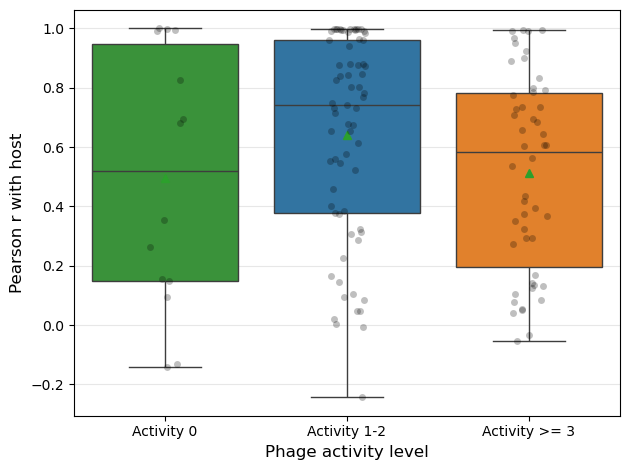

In [38]:
from scipy.stats import pearsonr

# Compute Pearson correlation per phage-bacteria pair
def pearson_from_lists(s):
    x = np.array(s["bac_cov_list"])
    y = np.array(s["phage_cov_list"])
    if len(x) < 2 or np.all(x == x[0]) or np.all(y == y[0]):
        return {"pearson_r": np.nan, "pearson_pval": np.nan}
    r, pval = pearsonr(x, y)
    return {"pearson_r": r, "pearson_pval": pval}

pearson_df = (
    paired
    .group_by(["coassembly_group", "Genus", "bac_contig", "phage_contig", "activity_level"])
    .agg([
        pl.col("bac_cov").alias("bac_cov_list"),
        pl.col("phage_cov").alias("phage_cov_list"),
        pl.len().alias("n_timepoints"),
    ])
    .with_columns(
        pl.struct(["bac_cov_list", "phage_cov_list"])
        .map_elements(pearson_from_lists)
        .alias("stats")
    )
    .unnest("stats")
    .drop(["bac_cov_list", "phage_cov_list"])
)

# Boxplot of Pearson correlation by activity level
top_pearson_per_phage = (
    pearson_df
            .group_by(['coassembly_group', 'phage_contig', 'Genus', 'activity_level'])
            .agg([
                pl.col('pearson_pval').min(),
                pl.col('pearson_r').max()
            ])
)
pearson_plot = top_pearson_per_phage.select(["activity_level", "pearson_r"]).to_pandas()

sns.boxplot(
    data=pearson_plot,
    x="activity_level",
    y="pearson_r",
    order=activity_levels,
    hue='activity_level',
    showmeans=True,
    showfliers=False
 )
sns.stripplot(
    data=pearson_plot,
    x="activity_level",
    y="pearson_r",
    order=activity_levels,
    color="black",
    alpha=0.25,
    dodge=False
 )
plt.xlabel("Phage activity level", fontsize=12)
plt.ylabel("Pearson r with host", fontsize=12)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [39]:
from scipy.stats import mannwhitneyu

# Prepare data
activity_0 = top_pearson_per_phage.filter(pl.col('activity_level') == 'Activity 0')['pearson_r'].to_numpy()
activity_1_2 = top_pearson_per_phage.filter(pl.col('activity_level') == 'Activity 1-2')['pearson_r'].to_numpy()
activity_3plus = top_pearson_per_phage.filter(pl.col('activity_level') == 'Activity >= 3')['pearson_r'].to_numpy()

# Remove NaN values
activity_0 = activity_0[~np.isnan(activity_0)]
activity_1_2 = activity_1_2[~np.isnan(activity_1_2)]
activity_3plus = activity_3plus[~np.isnan(activity_3plus)]

# Pairwise Mann-Whitney U tests
comparisons = [
    ('Activity 0', 'Activity 1-2', activity_0, activity_1_2),
    ('Activity 0', 'Activity >= 3', activity_0, activity_3plus),
    ('Activity 1-2', 'Activity >= 3', activity_1_2, activity_3plus)
]

print("Pairwise Mann-Whitney U tests (Bonferroni corrected α = 0.0167):")
print("-" * 70)
for group1, group2, data1, data2 in comparisons:
    stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"{group1} vs {group2}:")
    print(f"  U-statistic: {stat:.2f}, p-value: {p_val:.4} {sig}")
    print(f"  n1={len(data1)}, n2={len(data2)}")
    print()


from scipy.stats import kruskal

stat, p_value = kruskal(activity_0, activity_1_2, activity_3plus)
print(f"Kruskal-Wallis H-test:")
print(f"  H-statistic: {stat:.4f}, p-value: {p_value:.4f}")

Pairwise Mann-Whitney U tests (Bonferroni corrected α = 0.0167):
----------------------------------------------------------------------
Activity 0 vs Activity 1-2:
  U-statistic: 408.00, p-value: 0.3649 ns
  n1=14, n2=69

Activity 0 vs Activity >= 3:
  U-statistic: 358.00, p-value: 0.9031 ns
  n1=14, n2=50

Activity 1-2 vs Activity >= 3:
  U-statistic: 2159.00, p-value: 0.0196 *
  n1=69, n2=50

Kruskal-Wallis H-test:
  H-statistic: 5.3750, p-value: 0.0681


In [40]:
highest_r_per_phage = (
    pearson_df
    .group_by(['coassembly_group', 'phage_contig', 'Genus', 'activity_level'])
    .agg([
        pl.col('pearson_r').max().alias('max_pearson_r'),
    ])
    .join(
        pearson_df,
        on=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'],
        how='inner'
    )
    .filter(pl.col('pearson_r') == pl.col('max_pearson_r'))
    .unique(subset=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'], maintain_order=True)
)

# calculate proportion with p-value <= 0.05 for each activity level
(
    highest_r_per_phage
    .filter(pl.col('pearson_r') > 0)
    .group_by('activity_level')
    .agg([
        pl.col('pearson_pval').filter(pl.col('pearson_pval') <= 0.05).count().alias('sig_count'),
        pl.col('pearson_pval').count().alias('total_count'),
        (pl.col('pearson_pval').filter(pl.col('pearson_pval') <= 0.05).count() / pl.col('pearson_pval').count()).alias('proportion_sig')
    ])
)

activity_level,sig_count,total_count,proportion_sig
str,u32,u32,f64
"""Activity 0""",7,12,0.583333
"""Activity 1-2""",48,67,0.716418
"""Activity >= 3""",27,48,0.5625


In [41]:
lowest_r_per_phage = (
    pearson_df
    .group_by(['coassembly_group', 'phage_contig', 'Genus', 'activity_level'])
    .agg([
        pl.col('pearson_r').min().alias('min_pearson_r'),
    ])
    .join(
        pearson_df,
        on=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'],
        how='inner'
    )
    .filter(pl.col('pearson_r') == pl.col('min_pearson_r'))
    .unique(subset=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'], maintain_order=True)
)

# calculate proportion with p-value <= 0.05 for each activity level
(
    lowest_r_per_phage
    .filter(pl.col('pearson_r') < 0)
    .group_by('activity_level')
    .agg([
        pl.col('pearson_pval').filter(pl.col('pearson_pval') <= 0.05).count().alias('sig_count'),
        pl.col('pearson_pval').count().alias('total_count'),
        (pl.col('pearson_pval').filter(pl.col('pearson_pval') <= 0.05).count() / pl.col('pearson_pval').count()).alias('proportion_sig')
    ])
)

activity_level,sig_count,total_count,proportion_sig
str,u32,u32,f64
"""Activity 1-2""",0,23,0.0
"""Activity >= 3""",0,25,0.0
"""Activity 0""",0,5,0.0


shape: (728, 4)
┌──────────────────┬────────────────┬──────────────────┬─────────────┐
│ coassembly_group ┆ activity_level ┆ persistent_count ┆ cutoff_days │
│ ---              ┆ ---            ┆ ---              ┆ ---         │
│ str              ┆ str            ┆ u32              ┆ i32         │
╞══════════════════╪════════════════╪══════════════════╪═════════════╡
│ 14               ┆ Activity >= 3  ┆ 20               ┆ 250         │
│ 15               ┆ Bacteria       ┆ 50               ┆ 250         │
│ 1                ┆ Activity 0     ┆ 14               ┆ 250         │
│ 3                ┆ Activity 1-2   ┆ 23               ┆ 250         │
│ 7                ┆ Activity 1-2   ┆ 6                ┆ 250         │
│ …                ┆ …              ┆ …                ┆ …           │
│ 7                ┆ Activity 1-2   ┆ 1                ┆ 3000        │
│ 4                ┆ Activity 1-2   ┆ 4                ┆ 3000        │
│ 11               ┆ Activity 1-2   ┆ 1                ┆ 3000

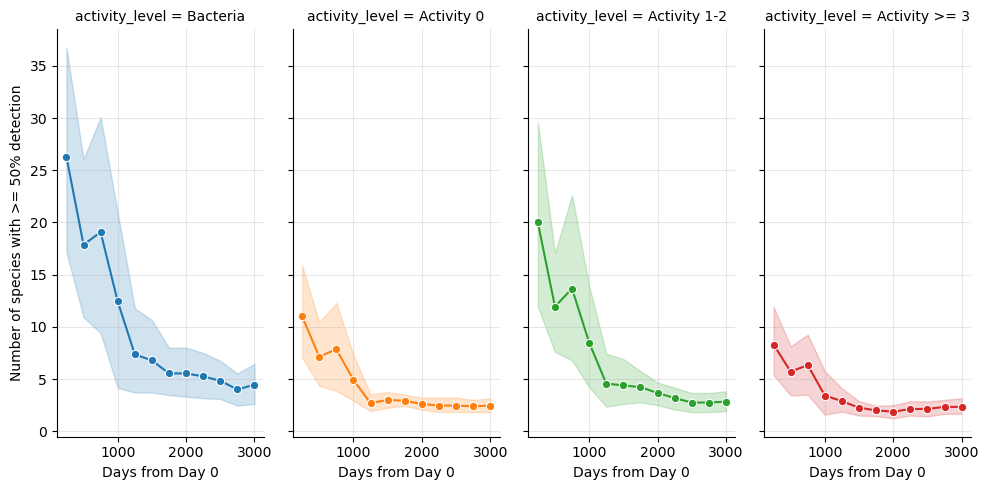

In [24]:
### Percent of day 0 species detected at 100-day intervals by activity level

# Build dataset from bacphlip with time normalization and activity levels
virus_data = (
    bacphlip
        .join(max_activity[['coassembly_group', 'contig', 'activity_level']], on=['coassembly_group', 'contig'], how='inner')
        .join(min_date_per_group, on='coassembly_group')
        .with_columns([
            (pl.col('timepoint') - pl.col('min_timepoint')).dt.total_days().alias('days_from_min')
        ])
        .filter(pl.col('True_cov') >= 4)
)

# Define cutoffs
cutoffs = [250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
results = []

for cutoff in cutoffs:
    # Filter data to timepoints up to this cutoff
    data_at_cutoff = virus_data.filter(pl.col('days_from_min') <= cutoff)
    
    # Get total samples per coassembly group at this cutoff
    total_samples = (
        data_at_cutoff
            .select(['coassembly_group', 'sample'])
            .unique()
            .group_by('coassembly_group')
            .agg(pl.len().alias('total_samples'))
    )
    
    # Calculate persistence per contig at this cutoff
    contig_persistence = (
        data_at_cutoff
            .group_by(['coassembly_group', 'contig', 'activity_level', 'genus', 'bac_genus'])
            .agg([
                pl.col('sample').n_unique().alias('samples_detected'),
                pl.col('True_cov').max().alias('max_cov')
            ])
            .join(total_samples, on='coassembly_group')
            .with_columns([
                (pl.col('samples_detected') / pl.col('total_samples')).alias('persistence')
            ])
            .filter(pl.col('persistence') >= 0.5)
    )
    
    # Count persistent contigs per coassembly group and activity level
    persistent_counts = (
        contig_persistence
            .group_by(['coassembly_group', 'activity_level'])
            .agg(pl.col('contig').n_unique().alias('persistent_count'))
            .with_columns([
                pl.lit(cutoff).alias('cutoff_days')
            ])
    )
    
    results.append(persistent_counts)

# Combine all results
persistence_by_cutoff = pl.concat(results)

print(persistence_by_cutoff)

# Plot as faceted line plot with individual points
import pandas as pd
plot_df = persistence_by_cutoff.to_pandas()


g = sns.relplot(
    data=plot_df,
    x='cutoff_days',
    y='persistent_count',
    col='activity_level',
    col_order=['Bacteria', 'Activity 0', 'Activity 1-2', 'Activity >= 3'],
    hue='activity_level',
    hue_order=['Bacteria', 'Activity 0', 'Activity 1-2', 'Activity >= 3'],
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1,
    marker='o',
    markersize=6
)

g.set_axis_labels('Days from Day 0', 'Number of species with >= 50% detection')
for ax in g.axes.flat:
    ax.grid(alpha=0.3)

# hide legend
g._legend.remove()
# change plot size
plt.gcf().set_size_inches(10, 5)
plt.tight_layout()
plt.show()


In [25]:
plot_df[(plot_df['activity_level'] == 'Bacteria') & (plot_df['cutoff_days'] == 1250)]['persistent_count'].mean()

np.float64(7.357142857142857)

In [26]:
plot_df[(plot_df['activity_level'] == 'Activity 0') & (plot_df['cutoff_days'] == 1250)]['persistent_count'].mean()

np.float64(2.6923076923076925)

In [27]:
plot_df[(plot_df['activity_level'] == 'Activity 1-2') & (plot_df['cutoff_days'] == 1250)]['persistent_count'].mean()

np.float64(4.571428571428571)

In [28]:
plot_df[(plot_df['activity_level'] == 'Activity >= 3') & (plot_df['cutoff_days'] == 3000)]['persistent_count'].mean()

np.float64(2.3333333333333335)

1
2
3
4
5
6
7
8
9


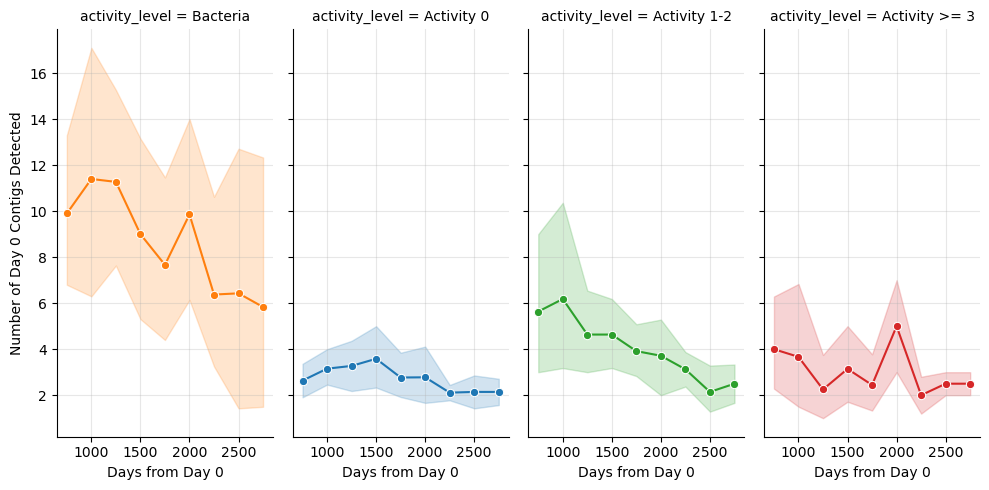

In [29]:
### Number of day 0 contigs detected at increasing intervals

# Get contigs detected at day 0 (timepoint 1)
day0_contigs = (
    virus_data
        .filter(pl.col('days_from_min') <= 500)
        .select(['coassembly_group', 'contig', 'activity_level'])
        .unique()
)

# Count day 0 contigs by activity level
day0_counts = (
    day0_contigs
        .group_by('activity_level')
        .agg(pl.col('contig').n_unique().alias('day0_count'))
)

# For each cutoff, count how many day 0 contigs are still detected
cutoffs = [500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
day0_detection_results = []

for i in range(1, len(cutoffs)-1):
    print(i)
    # Get contigs detected at or before this cutoff
    contigs_at_cutoff = (
        virus_data
            .filter(pl.col('days_from_min') <= cutoffs[i])
            .filter(pl.col('days_from_min') > cutoffs[i-1])
            .select(['coassembly_group', 'contig', 'activity_level'])
            .unique()
    )
    
    # Find overlap between day 0 contigs and contigs at this cutoff
    overlaps = (
        day0_contigs
            .join(contigs_at_cutoff, on=['coassembly_group', 'contig', 'activity_level'], how='inner')
    )
    
    # Count detected day 0 contigs per activity level
    detected_counts = (
        overlaps
            .group_by(['coassembly_group', 'activity_level'])
            .agg(pl.len().alias(f'detected_at_{cutoffs[i]}'))
    )
    
    # Combine with day 0 counts and calculate count
    detection_pct = (
        day0_counts
            .join(detected_counts, on='activity_level', how='left')
            .fill_null(0)
            .with_columns([
                pl.lit(cutoffs[i]).alias('cutoff_days'),
                pl.col(f'detected_at_{cutoffs[i]}').alias('contigs_detected')
            ])
            .select(['activity_level', 'cutoff_days', 'contigs_detected'])
    )
    
    day0_detection_results.append(detection_pct)

# Combine all results
day0_detection_by_cutoff = pl.concat(day0_detection_results, how='vertical')

# Plot as faceted line plot
plot_df = day0_detection_by_cutoff.select(['activity_level', 'cutoff_days', 'contigs_detected']).to_pandas()

g = sns.relplot(
    data=plot_df,
    x='cutoff_days',
    y='contigs_detected',
    col='activity_level',
    col_order=['Bacteria', 'Activity 0', 'Activity 1-2', 'Activity >= 3'],
    hue='activity_level',
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1,
    marker='o',
    markersize=6
)

g.set_axis_labels('Days from Day 0', 'Number of Day 0 Contigs Detected')
for ax in g.axes.flat:
    ax.grid(alpha=0.3)

# hide legend
g._legend.remove()
plt.gcf().set_size_inches(10, 5)
plt.tight_layout()
plt.show()